# Naive Bayes — Spam Filter (Realistic Dataset Embedded)

We build a text classification pipeline with EDA, baselines, CV, and tuning. To keep the repository self-contained, a small realistic SMS-like dataset is embedded directly.

**Author:** Olivier Robert-Duboille

**What you'll practice**
- reproducible data loading
- EDA with clear plots
- feature engineering / preprocessing pipelines
- cross-validation + hyperparameter tuning
- baseline vs advanced model comparison

This notebook is part of the *advanced-ml-mastery-collection* and is designed to be reproducible and portfolio-ready.

In [1]:
# Reproducibility
import os
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot settings
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_context('talk')


## Create dataset

In [2]:
import pandas as pd
import numpy as np

# Simple offline dataset + augmentation (deterministic)
data = [
    ('ham', 'Hey, are we still on for lunch tomorrow?'),
    ('ham', 'Please review the attached report before 5pm.'),
    ('ham', 'Can you call me when you have a minute?'),
    ('ham', 'Happy birthday! Hope you have a great day.'),
    ('ham', 'Your appointment is confirmed for Monday at 10:00.'),
    ('spam', 'WIN a brand new phone! Click http://bit.ly/free now!'),
    ('spam', 'Congratulations! You have been selected for a $1000 gift card. Reply YES'),
    ('spam', 'URGENT: Your account is suspended. Verify details at www.secure-login.example'),
    ('spam', 'Lowest rate loans available. Apply now and get approved today!'),
    ('spam', 'You have 1 new voicemail. Listen here: http://tinyurl.com/vm'),
]

ham_templates = [
    'Hi {name}, can you send the files?',
    "Let's meet at {time} at {place}.",
    'Thanks for your help on {topic}.',
]
spam_templates = [
    'Claim your prize of {amount}! Visit {url}',
    'Limited offer: {pct}% OFF. Buy now: {url}',
    'Act now to receive {amount} cash advance. Apply at {url}',
]

names = ['Alex','Sam','Jordan','Taylor','Morgan','Chris']
times = ['9am','noon','6pm','tomorrow','next week']
places = ['cafe','office','station','downtown']
topics = ['the presentation','the invoice','the project','the meeting']
amounts = ['$500','$1000','$2000']
urls = ['http://bit.ly/deal','http://tinyurl.com/claim','http://example.com/win']
pcts = [30,40,50,70]

rng = np.random.default_rng(SEED)
for _ in range(300):
    t = rng.choice(ham_templates)
    msg = t.format(name=rng.choice(names), time=rng.choice(times), place=rng.choice(places), topic=rng.choice(topics))
    data.append(('ham', msg))
for _ in range(300):
    t = rng.choice(spam_templates)
    msg = t.format(amount=rng.choice(amounts), url=rng.choice(urls), pct=rng.choice(pcts))
    data.append(('spam', msg))

df = pd.DataFrame(data, columns=['label','text'])
df = df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
df['y'] = (df['label'] == 'spam').astype(int)

display(df.head())
print(df['label'].value_counts())


,label,text,y
0,ham,Thanks for your help on the project.,0
1,ham,Thanks for your help on the project.,0
2,ham,"Hi Morgan, can you send the files?",0
3,spam,Act now to receive $1000 cash advance. Apply a...,1
4,ham,Let's meet at next week at station.,0


label
ham     305
spam    305
Name: count, dtype: int64


## EDA

Explore distributions, relationships, and potential issues (missing values, skew, outliers).

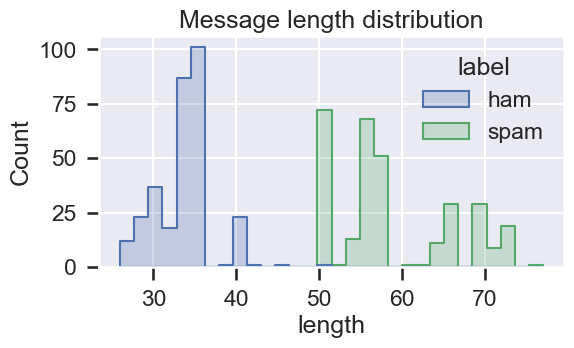

In [3]:
df['length'] = df['text'].str.len()

plt.figure(figsize=(6,3))
sns.histplot(data=df, x='length', hue='label', bins=30, element='step')
plt.title('Message length distribution')
plt.show()


## Baseline vs advanced models (CV)

In [4]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

X = df['text']
y = df['y']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
scoring = {'auc': 'roc_auc', 'f1': 'f1', 'acc': 'accuracy'}

dummy = Pipeline([('clf', DummyClassifier(strategy='most_frequent'))])
nb = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2)), ('clf', MultinomialNB())])
lr = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2)), ('clf', LogisticRegression(max_iter=5000, solver='liblinear'))])

import pandas as pd
rows = []
for name, model in [('dummy', dummy), ('mnb', nb), ('logreg', lr)]:
    res = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    rows.append({'model': name, 'auc': res['test_auc'].mean(), 'f1': res['test_f1'].mean(), 'acc': res['test_acc'].mean()})

display(pd.DataFrame(rows).sort_values('auc', ascending=False))


,model,auc,f1,acc
1,mnb,1.0,0.998347,0.998361
2,logreg,1.0,0.995041,0.995082
0,dummy,0.5,0.000000,0.500000


## Tune Naive Bayes smoothing

In [5]:
from sklearn.model_selection import GridSearchCV
import numpy as np

pipe = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2)), ('clf', MultinomialNB())])
grid = {'clf__alpha': np.logspace(-3, 0, 10)}
gs = GridSearchCV(pipe, grid, cv=cv, scoring='roc_auc', n_jobs=-1)
gs.fit(X, y)
print('Best AUC:', gs.best_score_)
print('Best alpha:', gs.best_params_)


Best AUC: 1.0
Best alpha: {'clf__alpha': np.float64(0.001)}


## Inspect tokens driving predictions

Inspect the most spam-indicative tokens learned by the model.

In [6]:
import numpy as np

best = gs.best_estimator_
best.fit(X, y)

vec = best.named_steps['tfidf']
clf = best.named_steps['clf']
feature_names = np.array(vec.get_feature_names_out())

# For MultinomialNB: log probabilities per class
spam_log_prob = clf.feature_log_prob_[1]
ham_log_prob = clf.feature_log_prob_[0]
diff = spam_log_prob - ham_log_prob
top = diff.argsort()[-20:][::-1]
display(pd.DataFrame({'token': feature_names[top], 'log_prob_diff(spam-ham)': diff[top]}))


,token,log_prob_diff(spam-ham)
0,http,10.308764
1,claim,10.174829
2,now,10.118642
3,com,10.081345
4,bit,9.781645
5,bit ly,9.781645
6,http bit,9.781645
7,ly,9.781645
8,limited,9.774195
9,limited offer,9.774195
